In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/DL/Transformer from Scratch

/content/drive/MyDrive/DL/Transformer from Scratch


In [3]:
# Thêm vào cell đầu tiên của notebook
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [ ]:
!python preprocess.py

Loading raw dataset...
README.md: 100% 543/543 [00:00<00:00, 3.41MB/s]
data/train-00000-of-00002.parquet: 100% 172M/172M [00:02<00:00, 81.4MB/s]
data/train-00001-of-00002.parquet: 100% 204M/204M [00:06<00:00, 30.8MB/s]
Generating train split: 100% 2977999/2977999 [00:02<00:00, 1370960.93 examples/s]
Building tokenizers...
[00:00:00] Tokenize words                 ██████████████████ 386156   /   386156
[00:00:00] Count pairs                    ██████████████████ 386156   /   386156
[00:00:04] Compute merges                 ██████████████████ 24769    /    24769
[00:00:00] Tokenize words                 ██████████████████ 329507   /   329507
[00:00:00] Count pairs                    ██████████████████ 329507   /   329507
[00:00:03] Compute merges                 ██████████████████ 25079    /    25079
Pre-tokenizing dataset...
Map: 100% 2977999/2977999 [01:30<00:00, 32982.49 examples/s]
Filtering long sentences...
Filter: 100% 2977999/2977999 [01:13<00:00, 40756.51 examples/s]
Dataset siz

In [ ]:
!pip install torchmetrics

In [ ]:
!python train.py

2025-12-13 10:27:20.185596: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765621640.207209    7738 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765621640.214687    7738 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765621640.232603    7738 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765621640.232632    7738 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765621640.232636    7738 computation_placer.cc:177] computation placer alr

Đang đọc dữ liệu từ: runs/tmodel/events.out.tfevents.1765621651.76a607487a95.7738.0
Các metrics tìm thấy: ['train loss', 'val loss', 'validation perplexity', 'Final Test BLEU']


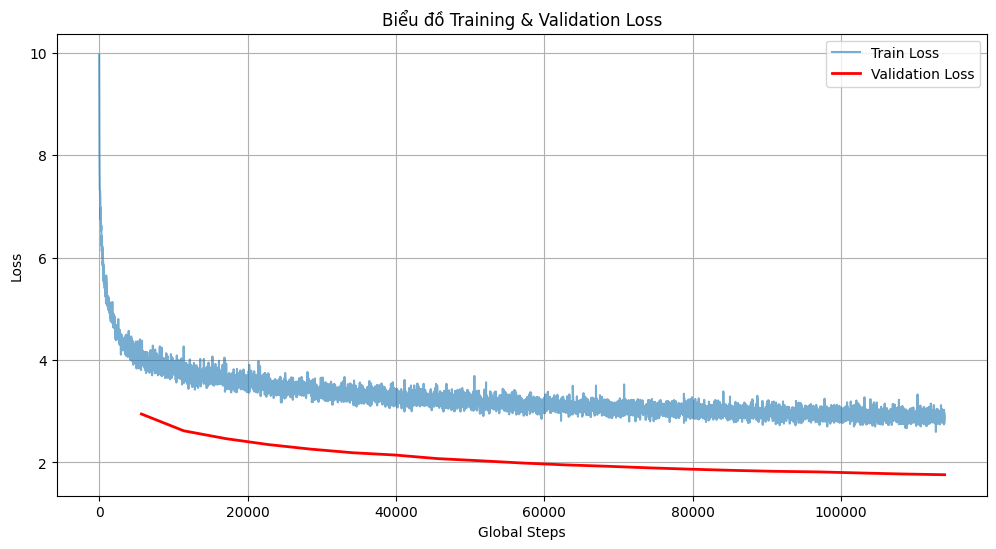

Đã lưu biểu đồ thành công vào training_chart.png


In [ ]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import glob

def plot_training_results(log_dir="runs/tmodel"):
    # Tìm file log mới nhất trong thư mục
    list_of_files = glob.glob(f'{log_dir}/*')
    if not list_of_files:
        print("Không tìm thấy file log nào trong thư mục:", log_dir)
        return

    # Lấy file mới nhất
    latest_file = max(list_of_files, key=os.path.getctime)
    print(f"Đang đọc dữ liệu từ: {latest_file}")

    # Load dữ liệu
    event_acc = EventAccumulator(latest_file)
    event_acc.Reload()

    # Lấy danh sách các thẻ (tags) có sẵn
    tags = event_acc.Tags()['scalars']
    print("Các metrics tìm thấy:", tags)

    # Chuẩn bị dữ liệu vẽ
    plt.figure(figsize=(12, 6))

    # 1. Vẽ Train Loss
    if 'train loss' in tags:
        train_loss = event_acc.Scalars('train loss')
        steps = [x.step for x in train_loss]
        values = [x.value for x in train_loss]
        plt.plot(steps, values, label='Train Loss', alpha=0.6)

    # 2. Vẽ Validation Loss
    if 'val loss' in tags:
        val_loss = event_acc.Scalars('val loss')
        v_steps = [x.step for x in val_loss]
        v_values = [x.value for x in val_loss]
        plt.plot(v_steps, v_values, label='Validation Loss', linewidth=2, color='red')

    plt.title("Biểu đồ Training & Validation Loss")
    plt.xlabel("Global Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Lưu ảnh
    plt.savefig("training_chart.png")
    plt.show()
    print("Đã lưu biểu đồ thành công vào training_chart.png")

# Chạy hàm vẽ
plot_training_results()

In [5]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.7 MB/s eta 0:00:00
